In [21]:
import pandas as pd
import numpy as np

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

In [22]:
X_train = pd.read_csv("datos_baterias_mp/X_train.csv")
X_test = pd.read_csv("datos_baterias_mp/X_test.csv")

y_voltage_train = pd.read_csv("datos_baterias_mp/y_voltage_train.csv").squeeze()
y_voltage_test = pd.read_csv("datos_baterias_mp/y_voltage_test.csv").squeeze()

y_volume_train = pd.read_csv("datos_baterias_mp/y_volume_train.csv").squeeze()
y_volume_test = pd.read_csv("datos_baterias_mp/y_volume_test.csv").squeeze()

In [23]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_voltage_train:", y_voltage_train.shape)
print("y_voltage_test:", y_voltage_test.shape)

print("y_volume_train:", y_volume_train.shape)
print("y_volume_test:", y_volume_test.shape)

X_train: (5477, 142)
X_test: (1370, 142)
y_voltage_train: (5477,)
y_voltage_test: (1370,)
y_volume_train: (5477,)
y_volume_test: (1370,)


### 1. Definir los modelos

In [24]:
models = {
    "Dummy": DummyRegressor(strategy="mean"),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )
}

El modelo Ridge es un modelo sensible a la escala de varibales y los descriptores de Magpie tienen escalas muy diferentes. Random Forest y XGBoost no necesitan ese escalado.


#### 2. Entrenamiento modelo Dummy para el voltaje

In [25]:
dummy_voltage = DummyRegressor(strategy="mean")

dummy_voltage.fit(
    X_train,
    y_voltage_train
)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None
Name,Type,Value
"constant_ constant_: ndarray of shape (1, n_outputs)Mean or median or quantile of the training targets or constant valuegiven by the user.","ndarray[float64](1, 1)",[[2.51]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](142,)","['MagpieData minimum Number','MagpieData maximum Number', 'MagpieData range Number',...,'working_ion_Rb','working_ion_Y', 'working_ion_Zn']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,142
n_outputs_ n_outputs_: intNumber of outputs.,int,1


In [26]:
y_pred_dummy = dummy_voltage.predict(X_test)

In [27]:
mae = mean_absolute_error(
    y_voltage_test,
    y_pred_dummy
)

rmse = np.sqrt(
    mean_squared_error(
        y_voltage_test,
        y_pred_dummy
    )
)

r2 = r2_score(
    y_voltage_test,
    y_pred_dummy
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.3877177227888724
RMSE: 1.8802152250180468
R²: -0.0004156083507447228


El R² ligeramente negativo significa que este modelo de referencia funciona un poco peor que utilizar directamente la media de y_test.

#### 3. Entrenamiento modelo Ridge para el voltaje

In [28]:
ridge_voltage = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

In [29]:
ridge_voltage.fit(
    X_train,
    y_voltage_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](142,)","['MagpieData minimum Number','MagpieData maximum Number', 'MagpieData range Number',...,'working_ion_Rb','working_ion_Y', 'working_ion_Zn']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,142
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [30]:
y_pred_ridge = ridge_voltage.predict(X_test)

In [31]:
mae = mean_absolute_error(
    y_voltage_test,
    y_pred_ridge
)

rmse = np.sqrt(
    mean_squared_error(
        y_voltage_test,
        y_pred_ridge
    )
)

r2 = r2_score(
    y_voltage_test,
    y_pred_ridge
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.7537421942456896
RMSE: 1.3231186640227917
R²: 0.5045921086750733


#### 4. Entrenamiento modelo Random Forest para el voltaje

In [32]:
rf_voltage = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [33]:
rf_voltage.fit(
    X_train,
    y_voltage_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [34]:
y_pred_rf = rf_voltage.predict(X_test)

In [35]:
mae = mean_absolute_error(
    y_voltage_test,
    y_pred_rf
)

rmse = np.sqrt(
    mean_squared_error(
        y_voltage_test,
        y_pred_rf
    )
)

r2 = r2_score(
    y_voltage_test,
    y_pred_rf
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.5966106888346532
RMSE: 1.2321428177136282
R²: 0.5703770939094177


#### 5. Entrenar modelo XGBoost para el voltaje

In [36]:
xgb_voltage = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

In [37]:
xgb_voltage.fit(
    X_train,
    y_voltage_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [38]:
y_pred_xgb = xgb_voltage.predict(X_test)

In [39]:
mae = mean_absolute_error(
    y_voltage_test,
    y_pred_xgb
)

rmse = np.sqrt(
    mean_squared_error(
        y_voltage_test,
        y_pred_xgb
    )
)

r2 = r2_score(
    y_voltage_test,
    y_pred_xgb
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.5623533593655899
RMSE: 1.2006836186367196
R²: 0.5920353815348671


#### 6. Comparación de resultados de modelos para el voltaje

In [40]:
results_voltage = pd.DataFrame({
    "Modelo": [
        "Dummy",
        "Ridge",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        mean_absolute_error(y_voltage_test, y_pred_dummy),
        mean_absolute_error(y_voltage_test, y_pred_ridge),
        mean_absolute_error(y_voltage_test, y_pred_rf),
        mean_absolute_error(y_voltage_test, y_pred_xgb)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_voltage_test, y_pred_dummy)),
        np.sqrt(mean_squared_error(y_voltage_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_voltage_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_voltage_test, y_pred_xgb))
    ],

    "R2": [
        r2_score(y_voltage_test, y_pred_dummy),
        r2_score(y_voltage_test, y_pred_ridge),
        r2_score(y_voltage_test, y_pred_rf),
        r2_score(y_voltage_test, y_pred_xgb)
    ]
})

results_voltage

,Modelo,MAE,RMSE,R2
0,Dummy,1.387718,1.880215,-0.000416
1,Ridge,0.753742,1.323119,0.504592
2,Random Forest,0.596611,1.232143,0.570377
3,XGBoost,0.562353,1.200684,0.592035


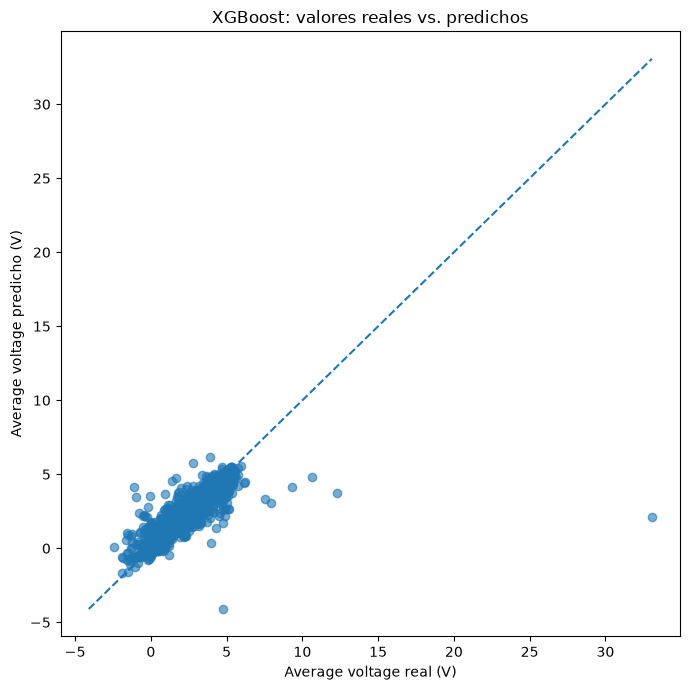

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    y_voltage_test,
    y_pred_xgb,
    alpha=0.6
)

# Línea ideal
min_value = min(
    y_voltage_test.min(),
    y_pred_xgb.min()
)

max_value = max(
    y_voltage_test.max(),
    y_pred_xgb.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Average voltage real (V)")
plt.ylabel("Average voltage predicho (V)")
plt.title("XGBoost: valores reales vs. predichos")

plt.tight_layout()
plt.show()

La Figura muestra la relación entre los valores reales y predichos de average_voltage para el modelo XGBoost. La concentración de observaciones alrededor de la diagonal significa que la capacidad predictiva del modelo, de forma global, es adecuada. No obstante, se observan algunas desviaciones importantes, especialmente para aquellos materiales con valores extremos de voltaje. Estas observaciones contribuyen a que el RMSE sea superior al MAE, lo que se traduce en una mayor dificultad del modelo para predecir determinados casos extremos.

#### 7. Entrenamiento modelo Dummy para el volumen

In [42]:
dummy_volume = DummyRegressor(strategy="mean")

dummy_volume.fit(
    X_train,
    y_volume_train
)

y_pred_dummy_volume = dummy_volume.predict(X_test)

mae = mean_absolute_error(
    y_volume_test,
    y_pred_dummy_volume
)

rmse = np.sqrt(
    mean_squared_error(
        y_volume_test,
        y_pred_dummy_volume
    )
)

r2 = r2_score(
    y_volume_test,
    y_pred_dummy_volume
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.6843047453651101
RMSE: 8.034471176937469
R²: -0.00010207923817362463


#### 7. Entrenamiento modelo Ridge para el volumen

In [43]:
ridge_volume = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_volume.fit(
    X_train,
    y_volume_train
)

y_pred_ridge_volume = ridge_volume.predict(X_test)

In [44]:
mae = mean_absolute_error(
    y_volume_test,
    y_pred_ridge_volume
)

rmse = np.sqrt(
    mean_squared_error(
        y_volume_test,
        y_pred_ridge_volume
    )
)

r2 = r2_score(
    y_volume_test,
    y_pred_ridge_volume
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.7069975654038989
RMSE: 7.632350145890967
R²: 0.09750187526903653


#### 9. Entrenamiento modelo Random Forest para el volumen

In [45]:
rf_volume = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_volume.fit(
    X_train,
    y_volume_train
)

y_pred_rf_volume = rf_volume.predict(X_test)

In [46]:
mae = mean_absolute_error(
    y_volume_test,
    y_pred_rf_volume
)

rmse = np.sqrt(
    mean_squared_error(
        y_volume_test,
        y_pred_rf_volume
    )
)

r2 = r2_score(
    y_volume_test,
    y_pred_rf_volume
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.4288240807544509
RMSE: 7.957592260114796
R²: 0.01894557485402215


#### 10. Entrenamiento modelo XGBoost para el volumen

In [47]:
xgb_volume = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

In [48]:
xgb_volume.fit(
    X_train,
    y_volume_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [49]:
y_pred_xgb_volume = xgb_volume.predict(X_test)

In [50]:
mae = mean_absolute_error(
    y_volume_test,
    y_pred_xgb_volume
)

rmse = np.sqrt(
    mean_squared_error(
        y_volume_test,
        y_pred_xgb_volume
    )
)

r2 = r2_score(
    y_volume_test,
    y_pred_xgb_volume
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.40206889427146786
RMSE: 7.930291233181249
R²: 0.025665659847130096


#### 11. Comparación modelos para volumen

In [51]:
results_volume = pd.DataFrame({
    "Modelo": [
        "Dummy",
        "Ridge",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        mean_absolute_error(y_volume_test, y_pred_dummy),
        mean_absolute_error(y_volume_test, y_pred_ridge),
        mean_absolute_error(y_volume_test, y_pred_rf),
        mean_absolute_error(y_volume_test, y_pred_xgb)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_volume_test, y_pred_dummy)),
        np.sqrt(mean_squared_error(y_volume_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_volume_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_volume_test, y_pred_xgb))
    ],

    "R2": [
        r2_score(y_volume_test, y_pred_dummy),
        r2_score(y_volume_test, y_pred_ridge),
        r2_score(y_volume_test, y_pred_rf),
        r2_score(y_volume_test, y_pred_xgb)
    ]
})

results_volume

,Modelo,MAE,RMSE,R2
0,Dummy,2.704173,8.291117,-0.065015
1,Ridge,2.869927,8.520942,-0.124877
2,Random Forest,2.884464,8.539404,-0.129756
3,XGBoost,2.883364,8.539490,-0.129779


Ninguno de los modelos consigue superar al Dummy y todos presentan un R² negativo, lo que indica que las variables no capturan la relación con el target (volumen). Además, la diferencia entre MAE y RMSE pone de manifiesto que existen algunos errores muy grandes, asociados a los valores extremos que toma el target.

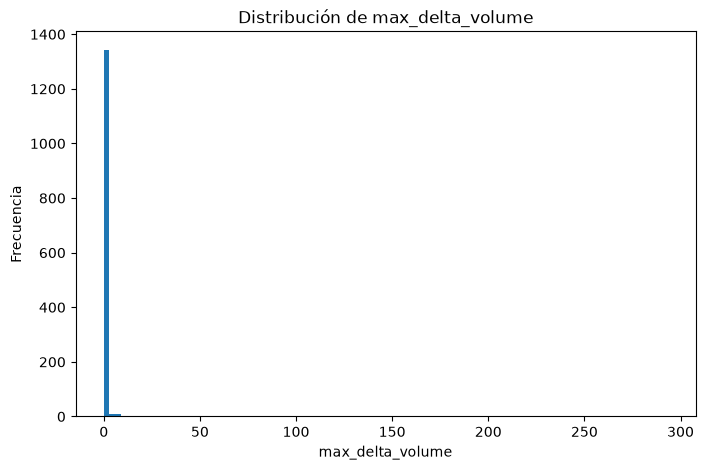

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(y_volume_test, bins=100)

plt.xlabel("max_delta_volume")
plt.ylabel("Frecuencia")
plt.title("Distribución de max_delta_volume")
plt.show()

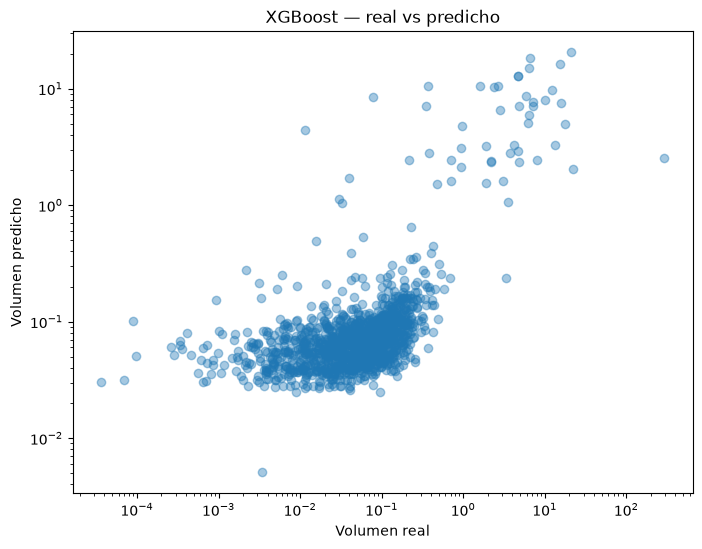

In [53]:
mask = (
    np.array(y_volume_test) > 0
) & (
    np.array(y_pred_xgb_volume) > 0
)

plt.figure(figsize=(8, 6))

plt.scatter(
    np.array(y_volume_test)[mask],
    np.array(y_pred_xgb_volume)[mask],
    alpha=0.4
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Volumen real")
plt.ylabel("Volumen predicho")
plt.title("XGBoost — real vs predicho")

plt.show()

In [54]:
y_volume_log_train = np.log1p(y_volume_train)
y_volume_log_test = np.log1p(y_volume_test)

In [55]:
xgb_volume.fit(X_train, y_volume_log_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [56]:
y_pred_log = xgb_volume.predict(X_test)

In [57]:
y_pred_volume = np.expm1(y_pred_log)

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_volume_test, y_pred_volume)
rmse = np.sqrt(mean_squared_error(y_volume_test, y_pred_volume))
r2 = r2_score(y_volume_test, y_pred_volume)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.37166155323644345
RMSE: 7.9342648849758275
R²: 0.02468899069888375


In [59]:
print("Real:", y_volume_test.iloc[:10].values)
print("Pred:", y_pred_volume[:10])

Real: [0.11933444 0.03720454 0.00035425 0.21505814 0.13842929 0.10525399
 0.00072808 0.01955949 0.05697173 0.00911368]
Pred: [0.09013781 0.02538517 0.0330335  0.10574766 0.03512593 0.07746131
 0.04940354 0.05304766 0.0559484  0.04728277]


In [60]:
errors = np.abs(
    y_volume_test.values - y_pred_volume
)

results = pd.DataFrame({
    "real": y_volume_test.values,
    "pred": y_pred_volume,
    "error": errors
})

results = results.sort_values("error", ascending=False)

print(results.head(20))

            real       pred       error
665   293.193218   2.013603  291.179615
849    22.470407   0.771400   21.699007
130    17.497218   1.940429   15.556789
999     6.513029  18.686152   12.173122
1305   13.165227   2.756640   10.408587
442    15.510963   7.865690    7.645273
1287    2.653610  10.197194    7.543584
477     0.079466   6.939326    6.859860
179     4.747871  11.391526    6.643655
1021    4.762574  11.391526    6.628952
398     7.932353   1.731634    6.200718
1339    2.381496   8.188947    5.807451
809     0.372839   5.350997    4.978158
884    20.696536  15.965567    4.730970
575    15.802936  11.290671    4.512265
380     0.347837   4.523098    4.175261
1099    6.488038   2.368972    4.119066
97      3.338915   0.112805    3.226110
144     4.899429   2.159597    2.739833
1242    6.166915   3.508319    2.658596


A partir de los experimentos realizados, se ha observado que los modelos de aprendizaje automático basados exclusivamente en variables tabulares presentan dificultades para predecir adecuadamente el cambio máximo de volumen (max_delta_volume) de los materiales de batería. El modelo Dummy obtuvo inicialmente mejores resultados que Ridge, Random Forest y XGBoost, con un \(R^2\) negativo en todos los modelos entrenados sobre el target original. Esto indica que las variables utilizadas no estaban proporcionando suficiente información para explicar la variabilidad del cambio de volumen.

Un aspecto especialmente relevante fue la distribución del target. Los valores de max_delta_volume presentan una fuerte asimetría, con la mayoría de las muestras concentradas en valores muy próximos a cero y un número reducido de casos con cambios de volumen extremadamente elevados, llegando en algunos casos hasta valores superiores a 290. Estos valores extremos tienen un impacto considerable sobre métricas como RMSE y \(R^2\), y dificultan que los modelos aprendan correctamente la relación entre las características de entrada y el cambio de volumen.

Para estudiar este problema se aplicó una transformación logarítmica al target mediante log1p. Esta modificación produjo una mejora significativa: el MAE se redujo de aproximadamente 2.88 a 0.37, el RMSE pasó de 8.54 a 7.93 y el \(R^2\) pasó de -0.13 a 0.025. La mejora del MAE muestra que el modelo consigue realizar predicciones más adecuadas para una gran parte de los materiales, aunque el \(R^2\) cercano a cero y el RMSE todavía elevado muestran que continúa existiendo una dificultad importante para predecir los casos extremos.

El análisis de los errores permitió comprobar que una parte importante del problema procede precisamente de estos valores extremos. Por ejemplo, para un material cuyo cambio de volumen real es 293.19, el modelo predice únicamente 1.90. También se observaron casos en los que el valor real es inferior a 1 mientras que la predicción alcanza valores superiores a 10. Esto pone de manifiesto que las variables tabulares empleadas hasta ahora no son capaces de representar suficientemente la información necesaria para caracterizar los cambios estructurales asociados al volumen.

Por este motivo, se considera que continuar únicamente con la optimización de modelos como Random Forest o XGBoost no constituye la estrategia más adecuada. El cambio de volumen de un material está directamente relacionado con su estructura cristalina, las posiciones de los átomos, las distancias interatómicas y la geometría de la red, aspectos que no quedan completamente representados mediante las variables tabulares utilizadas en este estudio.

Como siguiente paso, se plantea por tanto pasar de un enfoque basado principalmente en descriptores tabulares a un enfoque basado directamente en la estructura cristalina. Para ello, se estudiará el uso de representaciones de materiales mediante grafos cristalinos y modelos de deep learning específicos para materiales, como CGCNN o ALIGNN. Estos modelos permiten representar los átomos como nodos y sus relaciones espaciales como aristas, incorporando información geométrica de la estructura que puede ser especialmente relevante para predecir el cambio de volumen.

De esta manera, el objetivo de la siguiente etapa no será simplemente buscar un algoritmo con mejores métricas, sino comprobar si una representación más adecuada del material permite capturar la relación entre su estructura cristalina y su cambio de volumen, superando las limitaciones observadas en los modelos basados únicamente en características tabulares.

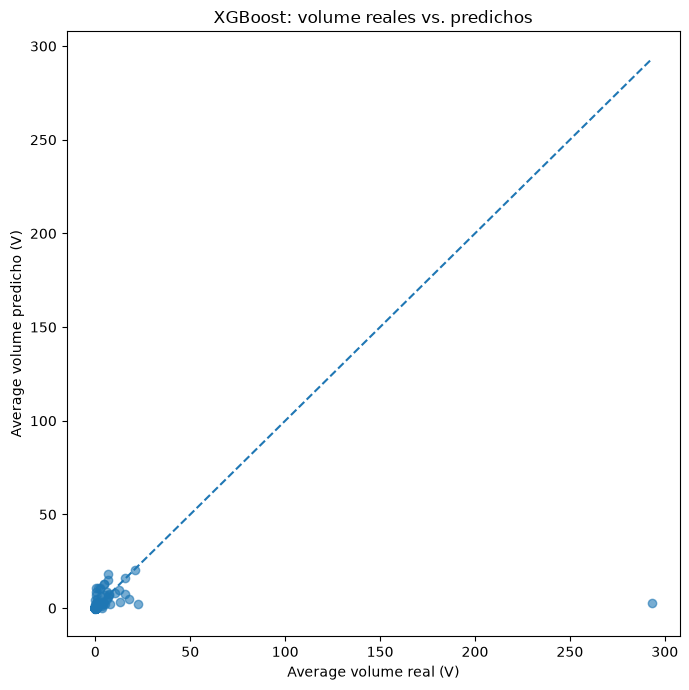

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    y_volume_test,
    y_pred_xgb_volume,
    alpha=0.6
)

# Línea ideal
min_value = min(
    y_volume_test.min(),
    y_pred_xgb_volume.min()
)

max_value = max(
    y_volume_test.max(),
    y_pred_xgb_volume.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Average volume real (V)")
plt.ylabel("Average volume predicho (V)")
plt.title("XGBoost: volume reales vs. predichos")

plt.tight_layout()
plt.show()

In [62]:
y_volume_train.describe()

count    5477.000000
mean        0.384515
std         4.911111
min         0.000016
25%         0.021815
50%         0.053416
75%         0.108876
max       267.323478
Name: max_delta_volume, dtype: float64

In [63]:
y_volume_test.describe()

count    1370.000000
mean        0.465687
std         8.036995
min         0.000036
25%         0.021847
50%         0.052533
75%         0.109844
max       293.193218
Name: max_delta_volume, dtype: float64

In [64]:
print("Mínimo:", y_volume_train.min())
print("Máximo:", y_volume_train.max())
print("Mediana:", y_volume_train.median())

Mínimo: 1.6222453393055503e-05
Máximo: 267.323477606053
Mediana: 0.05341584028621


In [65]:
y_volume_train.quantile(
    [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1]
)

0.00      0.000016
0.01      0.000838
0.05      0.004544
0.25      0.021815
0.50      0.053416
0.75      0.108876
0.95      0.349867
0.99      7.206750
1.00    267.323478
Name: max_delta_volume, dtype: float64

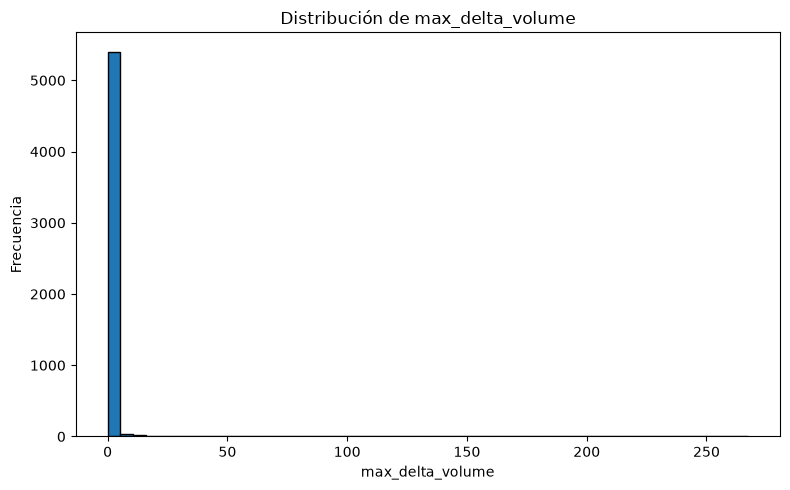

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    y_volume_train.dropna(),
    bins=50,
    edgecolor="black"
)

plt.xlabel("max_delta_volume")
plt.ylabel("Frecuencia")
plt.title("Distribución de max_delta_volume")

plt.tight_layout()
plt.show()

In [67]:
y_volume_train.quantile(
    [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1]
)

0.000      0.000016
0.010      0.000838
0.050      0.004544
0.250      0.021815
0.500      0.053416
0.750      0.108876
0.900      0.203775
0.950      0.349867
0.990      7.206750
0.995     13.065770
1.000    267.323478
Name: max_delta_volume, dtype: float64

In [68]:
print("Máximo:", y_volume_train.max())
print("Mediana:", y_volume_train.median())

Máximo: 267.323477606053
Mediana: 0.05341584028621


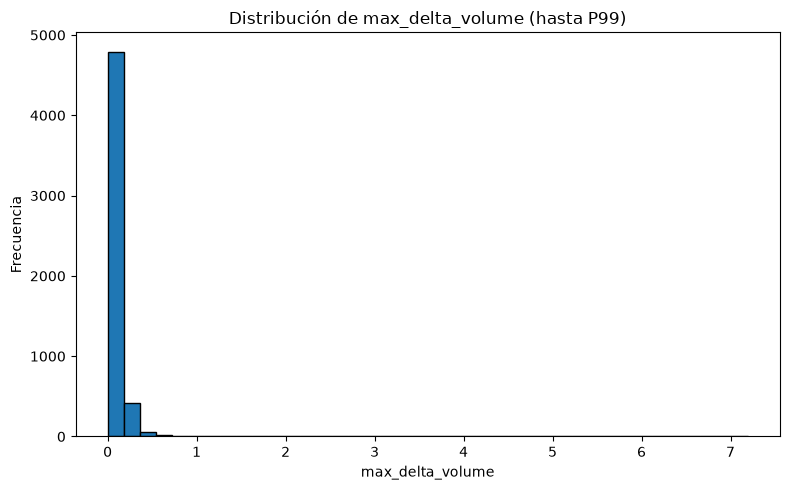

In [69]:
p99 = y_volume_train.quantile(0.99)

plt.figure(figsize=(8, 5))

plt.hist(
    y_volume_train[y_volume_train <= p99],
    bins=40,
    edgecolor="black"
)

plt.xlabel("max_delta_volume")
plt.ylabel("Frecuencia")
plt.title("Distribución de max_delta_volume (hasta P99)")

plt.tight_layout()
plt.show()

In [70]:
# Guardado del modelo entrenadao para Voltaje

from pathlib import Path
import json

MODEL_DIR = Path("modelos_finales")
MODEL_DIR.mkdir(exist_ok=True)

xgb_voltage.save_model(
    MODEL_DIR / "xgboost_voltage.json"
)

# Guardado de las columnas de características utilizadas para Voltaje

with open(
    MODEL_DIR / "voltage_feature_columns.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        X_train.columns.tolist(),
        f,
        indent=2
    )